# Feature Engineering Experiments — Titanic Dataset
**Tujuan:** Membuktikan secara empiris apakah setiap teknik feature engineering benar-benar membantu model.

Setiap eksperimen punya struktur:
1. Hipotesis — apa yang kamu prediksi akan terjadi
2. Implementasi
3. Hasil
4. Kesimpulan — apakah hipotesismu terbukti?

## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('D:\PythonProject\python-for-ai\day28-titanic-dataset\Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Preprocessing Dasar
Kita buat satu fungsi preprocessing yang akan dipakai di semua eksperimen supaya adil (apple-to-apple).

In [3]:
def base_preprocessing(df):
    """Preprocessing minimal yang dipakai di semua eksperimen."""
    data = df.copy()
    
    # Isi missing values
    data['Age'] = data['Age'].fillna(data['Age'].median())
    data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
    data['Fare'] = data['Fare'].fillna(data['Fare'].median())
    
    # Encode Sex
    data['Sex_enc'] = LabelEncoder().fit_transform(data['Sex'])
    
    # Encode Embarked
    data['Embarked_enc'] = LabelEncoder().fit_transform(data['Embarked'])
    
    return data

def evaluate_model(X, y, model_name='RandomForest'):
    """Evaluasi model dengan cross-validation, return mean F1 score."""
    if model_name == 'RandomForest':
        model = RandomForestClassifier(n_estimators=100, random_state=42)
    else:
        model = LogisticRegression(max_iter=1000, random_state=42)
    
    scores = cross_val_score(model, X, y, cv=5, scoring='f1')
    return scores.mean(), scores.std()

# Baseline features (tanpa engineering apapun)
BASELINE_FEATURES = ['Pclass', 'Age', 'Fare', 'Sex_enc', 'Embarked_enc', 'SibSp', 'Parch']

df_clean = base_preprocessing(df)
y = df_clean['Survived']

# Hitung baseline dulu
X_baseline = df_clean[BASELINE_FEATURES]
baseline_f1, baseline_std = evaluate_model(X_baseline, y)
print(f'Baseline F1: {baseline_f1:.4f} ± {baseline_std:.4f}')

Baseline F1: 0.7475 ± 0.0531


---
## Eksperimen 1 — Cross Feature: Sex × Pclass

### Hipotesis
> *Tuliskan prediksimu di sini sebelum lihat hasilnya.*
> 
> Contoh: "Aku prediksi cross feature Sex × Pclass akan meningkatkan F1 karena aturan evakuasi 'women and children first' sangat terkait dengan kelas penumpang."

**Hipotesismu:** ...

In [4]:
# --- Implementasi ---
df_exp1 = df_clean.copy()

# Cross feature: Sex × Pclass sebagai label string
df_exp1['Sex_x_Pclass'] = df_exp1['Sex'] + '_class' + df_exp1['Pclass'].astype(str)
df_exp1['Sex_x_Pclass_enc'] = LabelEncoder().fit_transform(df_exp1['Sex_x_Pclass'])

# Lihat kombinasi yang terbentuk
print('Kombinasi Sex × Pclass:')
print(df_exp1.groupby('Sex_x_Pclass')['Survived'].agg(['mean', 'count']))

Kombinasi Sex × Pclass:
                   mean  count
Sex_x_Pclass                  
female_class1  0.968085     94
female_class2  0.921053     76
female_class3  0.500000    144
male_class1    0.368852    122
male_class2    0.157407    108
male_class3    0.135447    347


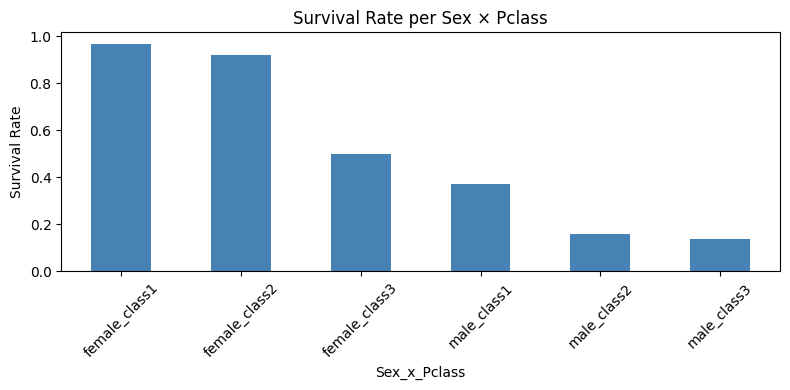

In [5]:
# Visualisasi survival rate per kombinasi
survival_by_group = df_exp1.groupby('Sex_x_Pclass')['Survived'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
survival_by_group.plot(kind='bar', color='steelblue')
plt.title('Survival Rate per Sex × Pclass')
plt.ylabel('Survival Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# Bandingkan performa model
features_exp1 = BASELINE_FEATURES + ['Sex_x_Pclass_enc']
X_exp1 = df_exp1[features_exp1]

f1_exp1, std_exp1 = evaluate_model(X_exp1, y)

print(f'Baseline F1 : {baseline_f1:.4f} ± {baseline_std:.4f}')
print(f'Exp 1 F1   : {f1_exp1:.4f} ± {std_exp1:.4f}')
print(f'Perubahan  : {f1_exp1 - baseline_f1:+.4f}')

Baseline F1 : 0.7475 ± 0.0531
Exp 1 F1   : 0.7482 ± 0.0455
Perubahan  : +0.0007


### Kesimpulan Eksperimen 1
> *Isi setelah lihat hasilnya.*
> 
> - Apakah F1 naik atau turun?
> - Apakah hipotesismu terbukti?
> - Kenapa menurutmu hasilnya begitu?

**Kesimpulanmu:** ...
f1 is raising but extremly low, its because the model we use is random forest
not yet because we use clasification models

---
## Eksperimen 2 — Domain Knowledge: Ekstrak Title dari Name

### Hipotesis
> Title (Mr, Mrs, Miss, Master, dll) mengandung informasi gender, usia, dan status sosial yang lebih kaya daripada fitur Sex dan Age secara terpisah.

**Hipotesismu:** yups , Title has more information over sex and age feature

In [7]:
# --- Implementasi ---
df_exp2 = df_clean.copy()

# Ekstrak title dari kolom Name
df_exp2['Title'] = df_exp2['Name'].str.extract(r',\s*([^.]+)\.')

print('Title yang ditemukan:')
print(df_exp2['Title'].value_counts())

Title yang ditemukan:
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


In [8]:
# Grupkan title yang jarang muncul ke 'Rare'
rare_titles = df_exp2['Title'].value_counts()[df_exp2['Title'].value_counts() < 10].index
df_exp2['Title'] = df_exp2['Title'].replace(rare_titles, 'Rare')

# Encode
df_exp2['Title_enc'] = LabelEncoder().fit_transform(df_exp2['Title'])

# Lihat survival rate per title
print('Survival rate per Title:')
print(df_exp2.groupby('Title')['Survived'].agg(['mean', 'count']))

Survival rate per Title:
            mean  count
Title                  
Master  0.575000     40
Miss    0.697802    182
Mr      0.156673    517
Mrs     0.792000    125
Rare    0.444444     27


In [ ]:
# Bandingkan 3 skenario:
# A) Baseline (tanpa Title)
# B) Baseline + Title
# C) Baseline + Title, tanpa Sex (karena Title sudah mengandung info gender)

X_A = df_exp2[BASELINE_FEATURES]
X_B = df_exp2[BASELINE_FEATURES + ['Title_enc']]
X_C = df_exp2[[f for f in BASELINE_FEATURES if f != 'Sex_enc'] + ['Title_enc']]

f1_A, _ = evaluate_model(X_A, y)
f1_B, _ = evaluate_model(X_B, y)
f1_C, _ = evaluate_model(X_C, y)

print(f'A) Baseline (tanpa Title)          : {f1_A:.4f}')
print(f'B) Baseline + Title                : {f1_B:.4f}')
print(f'C) Baseline + Title, tanpa Sex_enc : {f1_C:.4f}')

A) Baseline (tanpa Title)          : 0.7475
B) Baseline + Title                : 0.7445
C) Baseline + Title, tanpa Sex_enc : 0.7250


### Kesimpulan Eksperimen 2
> - Skenario mana yang terbaik?
> - Apakah Title bisa menggantikan Sex?
> - Apa yang bisa kamu pelajari dari ini?

**Kesimpulanmu:** nah bro, the baseline(without title) has more score, nope title feature cannot replace Sex, title do not effect much over age and sex

---
## Eksperimen 3 — FamilySize vs SibSp + Parch Terpisah

### Hipotesis


**Hipotesismu:**  i think familysize has more effect to increase score model predict survival

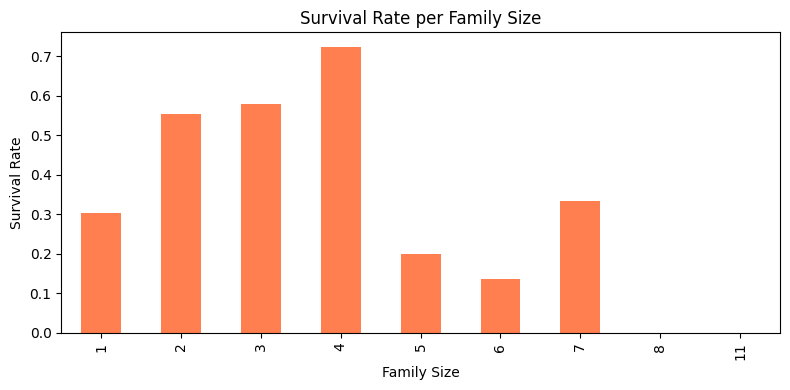

In [10]:
# --- Implementasi ---
df_exp3 = df_clean.copy()

# Buat FamilySize
df_exp3['FamilySize'] = df_exp3['SibSp'] + df_exp3['Parch'] + 1  # +1 untuk diri sendiri

# Visualisasi survival rate per FamilySize
plt.figure(figsize=(8, 4))
df_exp3.groupby('FamilySize')['Survived'].mean().plot(kind='bar', color='coral')
plt.title('Survival Rate per Family Size')
plt.ylabel('Survival Rate')
plt.xlabel('Family Size')
plt.tight_layout()
plt.show()

In [11]:
# Bandingkan 3 skenario:
# A) Baseline (SibSp + Parch terpisah)
# B) Ganti SibSp & Parch dengan FamilySize
# C) Semua ada (SibSp, Parch, FamilySize)

features_A = BASELINE_FEATURES  # sudah include SibSp dan Parch
features_B = [f for f in BASELINE_FEATURES if f not in ['SibSp', 'Parch']] + ['FamilySize']
features_C = BASELINE_FEATURES + ['FamilySize']

f1_A, _ = evaluate_model(df_exp3[features_A], y)
f1_B, _ = evaluate_model(df_exp3[features_B], y)
f1_C, _ = evaluate_model(df_exp3[features_C], y)

print(f'A) SibSp + Parch terpisah          : {f1_A:.4f}')
print(f'B) Ganti dengan FamilySize         : {f1_B:.4f}')
print(f'C) SibSp + Parch + FamilySize      : {f1_C:.4f}')

A) SibSp + Parch terpisah          : 0.7475
B) Ganti dengan FamilySize         : 0.7477
C) SibSp + Parch + FamilySize      : 0.7473


### Kesimpulan Eksperimen 3
> - Apakah menggabungkan SibSp + Parch menjadi FamilySize lebih baik?
> - Apakah ada pola menarik di visualisasi survival rate per FamilySize?

**Kesimpulanmu:** yes but just have a little different, we have interesting pattern if we see the barchart, family number equals to 4 has highest survival rate , i think its because the emergency boat has 4 seat 

---
## Eksperimen 4 — Semua Feature Engineering Digabung

Setelah tahu mana yang works dari eksperimen 1-3, sekarang gabungkan semuanya.

In [12]:
df_final = df_clean.copy()

# Gabungkan semua feature engineering terbaik
df_final['Sex_x_Pclass'] = df_final['Sex'] + '_class' + df_final['Pclass'].astype(str)
df_final['Sex_x_Pclass_enc'] = LabelEncoder().fit_transform(df_final['Sex_x_Pclass'])

df_final['Title'] = df_final['Name'].str.extract(r',\s*([^.]+)\.')
rare_titles = df_final['Title'].value_counts()[df_final['Title'].value_counts() < 10].index
df_final['Title'] = df_final['Title'].replace(rare_titles, 'Rare')
df_final['Title_enc'] = LabelEncoder().fit_transform(df_final['Title'])

df_final['FamilySize'] = df_final['SibSp'] + df_final['Parch'] + 1

# Pilih feature terbaik berdasarkan eksperimen 1-3
# TODO: sesuaikan berdasarkan hasil eksperimenmu!
BEST_FEATURES = [
    'Pclass', 'Age', 'Fare', 'Sex_enc', 'Embarked_enc',
    'Sex_x_Pclass_enc', 'Title_enc', 'FamilySize'
]

X_final = df_final[BEST_FEATURES]
f1_final, std_final = evaluate_model(X_final, y)

print(f'Baseline F1              : {baseline_f1:.4f}')
print(f'Final (all engineered)   : {f1_final:.4f}')
print(f'Total improvement        : {f1_final - baseline_f1:+.4f}')

Baseline F1              : 0.7475
Final (all engineered)   : 0.7402
Total improvement        : -0.0073


## Rangkuman Semua Eksperimen

In [13]:
# Tabel ringkasan — isi manual setelah semua eksperimen selesai
summary = {
    'Eksperimen': [
        'Baseline',
        'Exp 1: Sex × Pclass',
        'Exp 2: Title',
        'Exp 3: FamilySize',
        'Exp 4: Semua digabung'
    ],
    'F1 Score': [
        baseline_f1,
        f1_exp1,
        f1_B,      # skenario terbaik dari exp 2
        f1_B,      # skenario terbaik dari exp 3 — ganti dengan variabel yang benar
        f1_final
    ]
}

summary_df = pd.DataFrame(summary)
summary_df['vs Baseline'] = summary_df['F1 Score'] - baseline_f1
print(summary_df.to_string(index=False))

           Eksperimen  F1 Score  vs Baseline
             Baseline  0.747531     0.000000
  Exp 1: Sex × Pclass  0.748237     0.000706
         Exp 2: Title  0.747742     0.000211
    Exp 3: FamilySize  0.747742     0.000211
Exp 4: Semua digabung  0.740228    -0.007304


## Refleksi Akhir

> Isi setelah semua eksperimen selesai.

1. Feature engineering mana yang paling berdampak?
2. Ada hasil yang mengejutkan?
3. Apa yang akan kamu coba selanjutnya?

**Refleksimu:** watdehel i shock because if we do all engineering feature above we got performance degradation, i want to learn about feature engineering more and why is effect we are model